# Asset Comparison Tool

In [25]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import os
from custom_functions import calculate_technical_indicators, generate_trading_signals, find_trade_points, analyze_asset

## Parameters and Asset List
Set your analysis parameters and provide a list of tickers to analyze.

In [26]:
# Parameters
ASSET_FILE = 'assets_temporal.txt'
with open(ASSET_FILE, 'r') as f:
    ASSETS = [line.strip() for line in f if line.strip()]

MIN_ASSETS_REQUIRED = 2
RISK_FREE_RATE = 0.05  # Risk-free rate for Sharpe ratio calculation
MIN_SHARPE = 0.7       # Minimum Sharpe ratio threshold
MAX_DRAWDOWN = None    # Set to e.g. -0.4 for -40%, or None to ignore
START_DATE = datetime.now() - timedelta(days=365*2)
END_DATE = datetime.now()

## Data Collection and Analysis
Loop through each ticker, collect data, calculate metrics, and store results.

In [36]:
results = []
returns_dict = {}

for ticker in ASSETS:
    res = analyze_asset(ticker, START_DATE, END_DATE, RISK_FREE_RATE)
    if res is None:
        print(f"Skipping {ticker} due to insufficient data.")
        continue
    results.append(res)
    returns_dict[ticker] = res['returns']

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=['Sharpe', 'Sortino'], ascending=[False, False]).round(2)
print("\nInitial Asset Comparison (sorted by Sharpe & Sortino Ratios):")
results_df


Initial Asset Comparison (sorted by Sharpe & Sortino Ratios):


,Ticker,df,signals,buy_points,sell_points,returns,AnnReturn%,AnnVol%,Sharpe,Sortino,MaxDrawdown%,CurrentSignal,ann_return,ann_vol
0,META,Open H...,SMA RSI MACD Ind...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-11 00:00:00-04:00 0.006406 202...,33.40,36.80,0.77,0.77,-34.15,NEUTRAL,0.33,0.37
4,RPRX,Open Hig...,SMA RSI MACD Ind...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-11 00:00:00-04:00 -0.013582 202...,22.33,23.74,0.73,0.78,-16.36,NEUTRAL,0.22,0.24
5,CWAN,Open Hig...,SMA RSI MACD Ind...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-11 00:00:00-04:00 -0.005494 202...,32.88,41.11,0.68,0.79,-35.13,NEUTRAL,0.33,0.41
1,LDOS,Open H...,SMA RSI MACD Ind...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-11 00:00:00-04:00 0.003328 202...,19.25,29.15,0.49,0.44,-36.86,NEUTRAL,0.19,0.29
2,QCOM,Open H...,SMA RSI MACD Ind...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-11 00:00:00-04:00 0.024991 202...,3.02,42.08,-0.05,-0.05,-44.23,NEUTRAL,0.03,0.42
3,QRVO,Open H...,SMA RSI MACD Ind...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-10 00:00:00-04:00 False 2024-0...,Date 2024-04-11 00:00:00-04:00 0.021432 202...,-10.68,56.04,-0.28,-0.26,-60.68,NEUTRAL,-0.11,0.56


In [ ]:
from customsignals import plot_analysis

# Plot detailed technical analysis for each asset
plot_analysis(df, signals, buy_points, sell_points, ticker)
plt.savefig(f"{ticker}_analysis.png", dpi=300)
plt.close()

## Filter Assets
Apply Sharpe ratio and (optionally) drawdown filters.

In [15]:
# Apply filters based on user-defined criteria
filtered_df = filter_assets(results_df)

if len(filtered_df) < MIN_ASSETS_REQUIRED:
    print("\nWarning: Not enough assets meet the specified criteria.")
    print("Consider adjusting the filtering thresholds.")
    print(f"Falling back to minimum Sharpe ratio filter ({MIN_SHARPE})...")
    filtered_df = results_df[results_df['Sharpe'] >= MIN_SHARPE]

filtered_tickers = filtered_df['Ticker'].tolist()

# Print applied filters
print("\nApplied Filters:")
print(f"Minimum Sharpe Ratio: {MIN_SHARPE}")

if MAX_DRAWDOWN is not None:
    print(f"Maximum Drawdown: {MAX_DRAWDOWN*100:.1f}%")



Consider adjusting the filtering thresholds.
Falling back to minimum Sharpe ratio filter (0.7)...

Applied Filters:
Minimum Sharpe Ratio: 0.7


## Efficient Frontier Plot
Plot the efficient frontier and highlight assets, min volatility, and max Sharpe portfolios.

In [16]:
if len(filtered_df) >= MIN_ASSETS_REQUIRED:
    filtered_tickers = filtered_df['Ticker'].tolist()
    returns_matrix = pd.DataFrame({t: returns_dict[t] for t in filtered_tickers}).dropna()
    valid_tickers = list(returns_matrix.columns)
    mean_returns = returns_matrix.mean() * 252
    cov_matrix = returns_matrix.cov() * 252
    num_portfolios = 5000
    port_returns = []
    port_vols = []
    port_sharpes = []
    port_weights = []
    for _ in range(num_portfolios):
        weights = np.random.dirichlet(np.ones(len(valid_tickers)), size=1)[0]
        port_weights.append(weights)
        port_return = np.dot(weights, mean_returns[valid_tickers])
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix.loc[valid_tickers, valid_tickers], weights)))
        sharpe = port_return / port_vol if port_vol > 0 else 0
        port_returns.append(port_return)
        port_vols.append(port_vol)
        port_sharpes.append(sharpe)
    port_returns = np.array(port_returns)
    port_vols = np.array(port_vols)
    port_sharpes = np.array(port_sharpes)
    port_weights = np.array(port_weights)
    min_vol_idx = np.argmin(port_vols)
    max_sharpe_idx = np.argmax(port_sharpes)
    asset_vols = filtered_df.set_index('Ticker').loc[valid_tickers]['ann_vol'].values
    asset_returns = filtered_df.set_index('Ticker').loc[valid_tickers]['ann_return'].values
    asset_labels = valid_tickers
    # Top 5 assets by max Sharpe portfolio weight
    top5_indices = np.argsort(port_weights[max_sharpe_idx])[-5:][::-1]
    top5_assets = [valid_tickers[i] for i in top5_indices]
    top5_weights = port_weights[max_sharpe_idx][top5_indices]
    print('Top 5 assets by max Sharpe portfolio weight:')
    for t, w in zip(top5_assets, top5_weights):
        print(f'{t}: {w:.2%}')
    plt.figure(figsize=(10,6))
    plt.plot(port_vols, port_returns, label='Efficient frontier', color='dodgerblue')
    plt.scatter(asset_vols, asset_returns, marker='o', color='black', label='assets')
    for i, label in enumerate(asset_labels):
        plt.annotate(label, (asset_vols[i], asset_returns[i]), textcoords='offset points', xytext=(5,5), ha='left', fontsize=9)
    plt.scatter(port_vols[min_vol_idx], port_returns[min_vol_idx], marker='*', color='red', s=200, label='Minimum Volatility')
    plt.scatter(port_vols[max_sharpe_idx], port_returns[max_sharpe_idx], marker='*', color='limegreen', s=200, label='Maximum Sharpe Ratio')
    plt.xlabel('Volatility (Risk)')
    plt.ylabel('Expected Return')
    plt.title('Efficient Frontier with Asset Risk/Return')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Not enough assets to plot the efficient frontier.')

Not enough assets to plot the efficient frontier.


## Correlation Analysis

Correlation Matrix:
      META
META   1.0


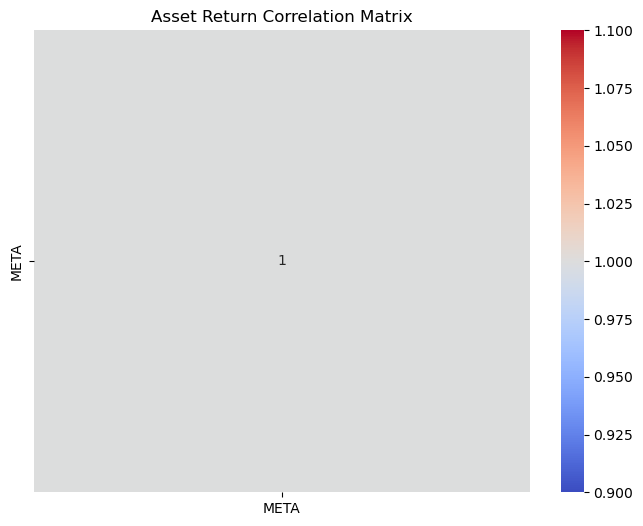

In [17]:
import seaborn as sns
returns_matrix = pd.DataFrame({t: returns_dict[t] for t in filtered_tickers}).dropna()
# Correlation matrix and heatmap
corr = returns_matrix.corr()
print("Correlation Matrix:")
print(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Asset Return Correlation Matrix")
plt.show()

## Comprehensive Stock Analysis Visualization

In [18]:
from customsignals import plot_analysis

# Plot detailed technical analysis for each asset
plot_analysis(df, signals, buy_points, sell_points, ticker)
plt.savefig(f"{ticker}_analysis.png", dpi=300)
plt.close()

## Statistical Robustness Checks (Bootstrap CI for Mean Return)

In [19]:
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_bootstrap)]
    lower = np.percentile(means, (100-ci)/2)
    upper = np.percentile(means, 100-(100-ci)/2)
    return lower, upper

print("\nBootstrap 95% Confidence Intervals for Mean Daily Return:")
for ticker, returns in returns_dict.items():
    lower, upper = bootstrap_ci(returns)
    print(f"{ticker}: Mean return 95% CI: [{lower:.4f}, {upper:.4f}]")


Bootstrap 95% Confidence Intervals for Mean Daily Return:
META: Mean return 95% CI: [-0.0012, 0.0040]
LDOS: Mean return 95% CI: [-0.0013, 0.0030]
QCOM: Mean return 95% CI: [-0.0028, 0.0030]
QRVO: Mean return 95% CI: [-0.0047, 0.0034]
RPRX: Mean return 95% CI: [-0.0009, 0.0025]
CWAN: Mean return 95% CI: [-0.0017, 0.0041]


## Backtesting of Trading Signals

In [20]:
from customsignals import backtest_strategy

strategy_return, buy_hold_return, portfolio_history = backtest_strategy(df, buy_points, sell_points)
print(f"{ticker}: Strategy Return: {strategy_return:.2f}%, Buy & Hold Return: {buy_hold_return:.2f}%")

CWAN: Strategy Return: 6.43%, Buy & Hold Return: 32.17%
